## Evaluate performance of zero-shot transfer for all repeated runs


In [ ]:
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib as mpl
from plotting_routines import *

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'eval_transferability')[0]

out_dir = os.path.sep.join([base_dir, 'figures', 'figures_transfer_alliters'])
os.makedirs(out_dir, exist_ok=True)

In [2]:
colors = sns.color_palette('colorblind')

def lighten(color, amount=0.3):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - x) * (1 - amount) for x in c)

colors_dict = {"ERAI": colors[0], 
                "CESM2": colors[2], 
                "ERAI & CESM2": colors[3],
                "ECE": colors[4],  
                "CESM2future": lighten(colors[2], 0.5), 
                "ECEfuture": lighten(colors[4], 0.5),
                'ERAI & CESM2future': lighten(colors[3], 0.5),
                'CESM2future_norain': colors[5],
                'CESM2future_noprecip': colors[6],
                'CESM2future_mono': colors[7],
                'CESM2future_shortterm': colors[9],
                'CESM2future_physical': colors[8]}

metrics_labels = {'RMSE': ('RMSE', 'mm w.e. per day'), 'MAE': ('MAE', 'mm w.e. per day'), 'MBE': ('MBE', 'mm w.e. per day'), 'total AE': ('mean annual absolute error', 'Gt'),
                  'residual': ('mean annual residual', 'Gt'), 'relative AE': ('mean annual relative error', '%'), 'residual_rel': ('mean annual relative residual', '%')}

In [3]:
MODEL_SPECS = ['ERAI', 'CESM2', 'ECE', 'ERAICESM2_2500', 'CESM2future', 'ECEfuture', 'ERAICESM2future_2500']
DATA_SPECS = ['ERAI', 'CESM2', 'ECE', 'CESM2future', 'ECEfuture']

EVAL_SPECS = {k: DATA_SPECS for k in MODEL_SPECS}

# iterations of lowest MAE across all years
BEST_ITERS = {'ERAI': 10,
              'CESM2': 15,
              'ERAI & CESM2': 7,
              'CESM2future': 18,
              'ECE': 6,
              'ECEfuture': 12,
              'ERAI & CESM2future': 18,
              'CESM2future_norain': 10,
              'CESM2future_noprecip': 2,
              'CESM2future_mono': 11,
              'CESM2future_shortterm': 8,
              'CESM2future_physical': 14,
              }

In [4]:
# Load all model scores

scaling_factor = 1.796553703424 / 58391     # conversion factor for whole ice sheet (mm --> Gt)

scores = {model: {} for model in EVAL_SPECS}

for model_spec, data_specs in EVAL_SPECS.items():
    pred_dir = os.path.sep.join([base_dir, 'output', f'repeated_{model_spec}_modularNNEBM_log'])
    print(f'Model {model_spec}: {pred_dir}')
    for data_spec in data_specs:
        scores_file = os.path.sep.join([pred_dir, f'scores_per_year_{data_spec}.csv'])
        print(f'  Data {data_spec}: {scores_file}')
        try:
            df = pd.read_csv(scores_file, index_col=[0,1,2])
            df.loc[:,'total AE'] = df['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
            df.loc[:,'relative AE'] = df['total AE'] / df['true melt'] * 100       # MAE relative to the years' respective melt
            df.loc[:,'residual_rel'] = df.loc[:, 'residual_rel'] * 100
            scores[model_spec][data_spec] = df
        except:
            pass


# rename combined models
replacements = {"ERAICESM2_2500": "ERAI & CESM2", "ERAICESM2future_2500": "ERAI & CESM2future"}
scores = {replacements.get(k, k): v for k, v in scores.items()}
MODEL_SPECS = ['ERAI', 'CESM2', 'ECE', 'ERAI & CESM2', 'CESM2future', 'ECEfuture', 'ERAI & CESM2future']

Model ERAI: /home/eschlager/MeltEmulation/output/repeated_ERAI_modularNNEBM_log
  Data ERAI: /home/eschlager/MeltEmulation/output/repeated_ERAI_modularNNEBM_log/scores_per_year_ERAI.csv
  Data CESM2: /home/eschlager/MeltEmulation/output/repeated_ERAI_modularNNEBM_log/scores_per_year_CESM2.csv
  Data ECE: /home/eschlager/MeltEmulation/output/repeated_ERAI_modularNNEBM_log/scores_per_year_ECE.csv
  Data CESM2future: /home/eschlager/MeltEmulation/output/repeated_ERAI_modularNNEBM_log/scores_per_year_CESM2future.csv
  Data ECEfuture: /home/eschlager/MeltEmulation/output/repeated_ERAI_modularNNEBM_log/scores_per_year_ECEfuture.csv
Model CESM2: /home/eschlager/MeltEmulation/output/repeated_CESM2_modularNNEBM_log
  Data ERAI: /home/eschlager/MeltEmulation/output/repeated_CESM2_modularNNEBM_log/scores_per_year_ERAI.csv
  Data CESM2: /home/eschlager/MeltEmulation/output/repeated_CESM2_modularNNEBM_log/scores_per_year_CESM2.csv
  Data ECE: /home/eschlager/MeltEmulation/output/repeated_CESM2_modu

In [5]:
# True melt per dataset: mean +/- std across the years
true_melt = pd.Series()
for dataset in DATA_SPECS:
    melt = scores[dataset][dataset]['true melt']
    true_melt[dataset] = melt.mean()
    print(dataset, round(melt.mean()), '+/-', round(melt.std()))

ERAI 621 +/- 138
CESM2 962 +/- 186
ECE 850 +/- 163
CESM2future 2734 +/- 454
ECEfuture 2582 +/- 373


/tmp/ipykernel_1781940/3024152298.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


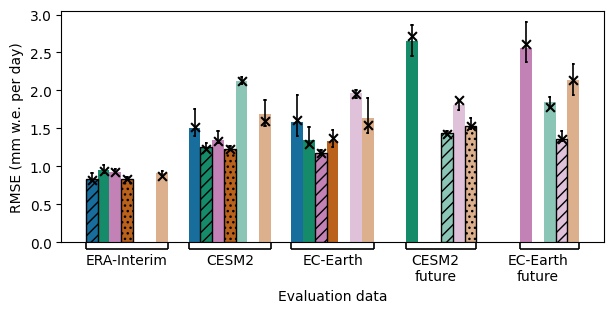

/tmp/ipykernel_1781940/3024152298.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


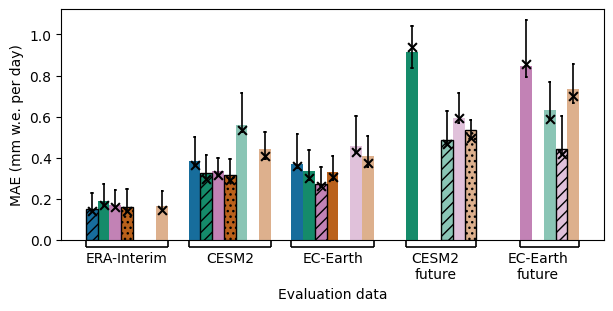

/tmp/ipykernel_1781940/3024152298.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


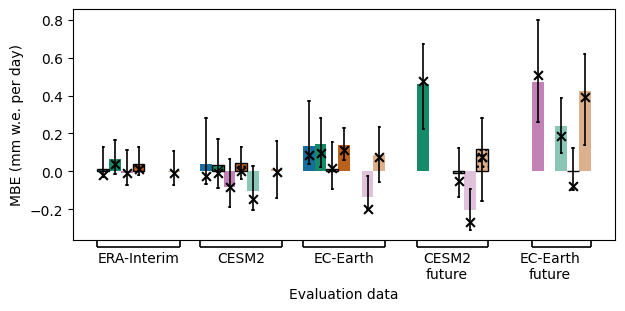

/tmp/ipykernel_1781940/3024152298.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


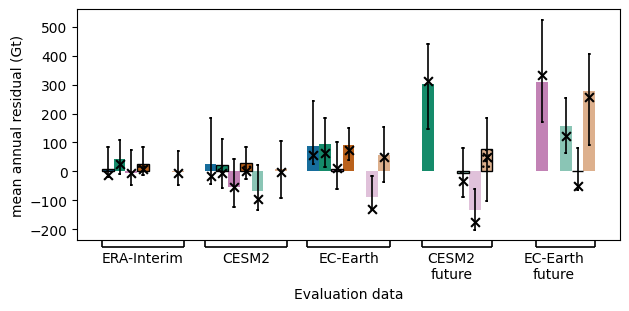

/tmp/ipykernel_1781940/3024152298.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


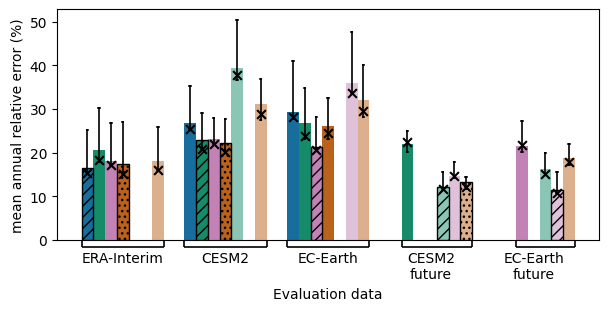

/tmp/ipykernel_1781940/3024152298.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


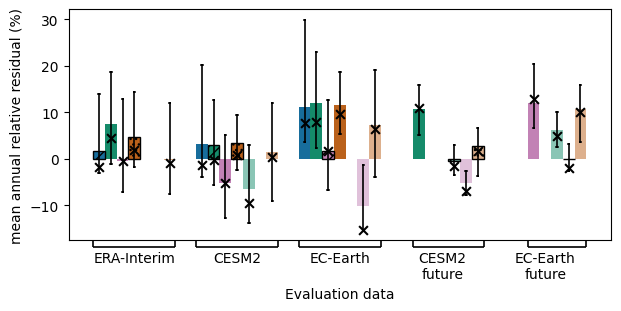

In [6]:
data_labels = {'ERAI': 'ERA-Interim', 'CESM2': 'CESM2', 'CESM2future': 'CESM2 future', 
                'ECE': 'EC-Earth', 'ECEfuture': 'EC-Earth future'}

for metric in ['RMSE', 'MAE', 'MBE', 'residual', 'relative AE', 'residual_rel']:
    rows = []

    for model in scores.keys():

        long_df = pd.concat(
            [
                df.assign(dataset=name)
                for name, df in scores[model].items()
            ]
        ).reset_index()

        # mean metric per training run and evaluation dataset
        tmp = (
            long_df
            .groupby(["dataset", "iter"])[metric]
            .mean()
            .reset_index()
        )

        tmp["model"] = model
        rows.append(tmp)

    plot_df = pd.concat(rows, ignore_index=True)
    plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=DATA_SPECS, ordered=True)
    plot_df["model"] = pd.Categorical(plot_df["model"], categories=MODEL_SPECS, ordered=True)

    plot_df = plot_df.sort_values(["dataset", "model", "iter"])

    plot_df["best_iter"] = (
    plot_df["iter"]
    == plot_df["model"].map(BEST_ITERS)
    )

    plot_df = plot_df.sort_values(["dataset", "model", "iter"])

    plt.figure(figsize=(7, 3))

    ax = sns.barplot(
        data=plot_df,
        x="dataset",
        y=metric,
        hue="model",
        order=DATA_SPECS,
        hue_order=MODEL_SPECS,
        estimator="median",
        errorbar=(lambda x: (x.min(), x.max())),    
        capsize=0.1,
        palette=colors_dict
    )

    #plt.legend(title="Model training data", loc="lower left", bbox_to_anchor=(0., -.65), ncols=4)
    legend_handles, labels = plt.gca().get_legend_handles_labels()
    ax.get_legend().remove()    # plot legend separately

    draw_brackets_instead_of_ticks(ax)

    ax = hatch_bar(ax, plot_df)

    ax = best_iter_scatter(ax, plot_df, metric)

    plt.ylabel(f'{metrics_labels[metric][0]} ({metrics_labels[metric][1]})')
    
    plt.xlabel("Evaluation data")
    ax = plt.gca()

    ax.set_xticklabels(
        [data_labels.get(t.get_text(), t.get_text()).replace(' ', '\n')
        for t in ax.get_xticklabels()]
    )
    
    plt.savefig(os.path.sep.join([out_dir, f'median_{metric}_per_model_hatched.pdf']), bbox_inches='tight')
    plt.show()

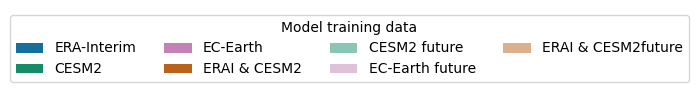

In [7]:
fig, ax = plt.subplots(figsize=(8, 1))
ax.axis("off")

for h in legend_handles:
    h.set_hatch(None)
    h.set_linewidth(0)


fig.legend(
    legend_handles,
    [data_labels.get(l, l) for l in labels],
    title="Model training data",
    loc="center",
    ncols=4,
)

plt.savefig(os.path.sep.join([out_dir, "legend.pdf"]), bbox_inches="tight")
plt.show()

## For extra experiments

In [8]:
# Load scores of extra experiments
model_spec = 'CESM2future'
for model_suffix, model_dir in {'_norain': f'repeated_{model_spec}_modularNNEBS_log', '_noprecip': f'repeated_{model_spec}_modularNNEB_log', 
                                '_mono': f'repeated_{model_spec}_modularNNEBMmono100_log', '_shortterm': f'repeated_{model_spec}_shorttermNN_log',
                                '_physical': f'repeated_{model_spec}_modularNNEBMphysical20onlyabove10mm_log'}.items():

    pred_dir = os.path.sep.join([base_dir, 'output', model_dir])
    print(f'Model {model_spec}: {pred_dir}')
    scores[model_spec+model_suffix] = {}
    for data_spec in data_specs:
        scores_file = os.path.sep.join([pred_dir, f'scores_per_year_{data_spec}.csv'])
        print(f'  Data {data_spec}: {scores_file}')
        try:
            df = pd.read_csv(scores_file, index_col=[0,1,2])
            df.loc[:,'total AE'] = df['MAE'] * scaling_factor * 58391 * 365.25     # MAE converted to total Gt per year
            df.loc[:,'relative AE'] = df['total AE'] / df['true melt'] * 100
            # df.loc[:,'bias'] = df['MBE'] * scaling_factor * 58391 * 365.25       # equal to residual
            # df.loc[:,'bias_rel'] = df.loc[:,'bias'] / df['true melt'] * 100    # equal to residual_rel
            df.loc[:,'residual_rel'] = df.loc[:, 'residual_rel'] * 100 
            scores[model_spec+model_suffix][data_spec] = df
        except:
            print('passed')
            pass

Model CESM2future: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBS_log
  Data ERAI: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBS_log/scores_per_year_ERAI.csv
passed
  Data CESM2: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBS_log/scores_per_year_CESM2.csv
  Data ECE: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBS_log/scores_per_year_ECE.csv
passed
  Data CESM2future: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBS_log/scores_per_year_CESM2future.csv
  Data ECEfuture: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEBS_log/scores_per_year_ECEfuture.csv
Model CESM2future: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEB_log
  Data ERAI: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEB_log/scores_per_year_ERAI.csv
passed
  Data CESM2: /home/eschlager/MeltEmulation/output/repeated_CESM2future_modularNNEB_log/sco

/tmp/ipykernel_1781940/3925384797.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


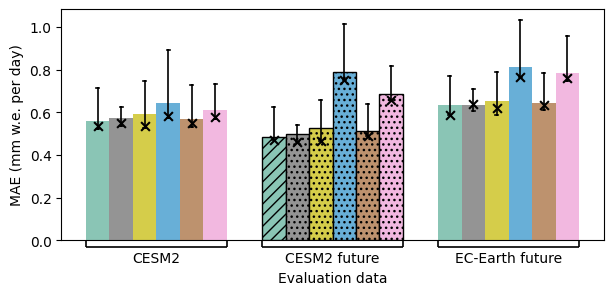

/tmp/ipykernel_1781940/3925384797.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


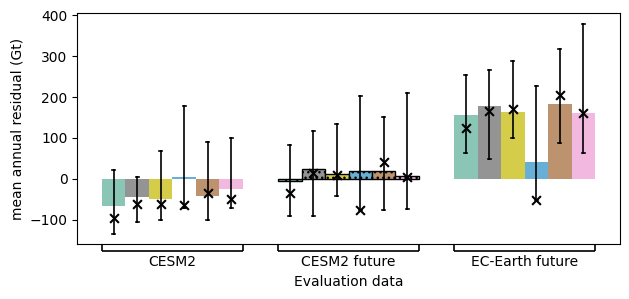

/tmp/ipykernel_1781940/3925384797.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


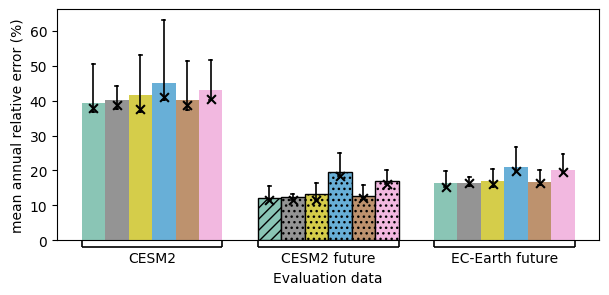

/tmp/ipykernel_1781940/3925384797.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


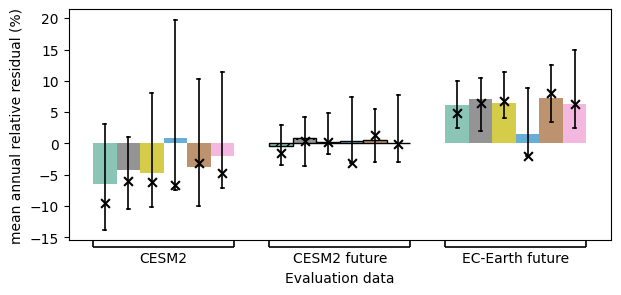

In [ ]:
DATA_SPECS = ['CESM2', 'CESM2future', 'ECEfuture']
model_labels = {'CESM2future': 'default', 
                'CESM2future_mono': 'with monotonic loss', 'CESM2future_physical': 'with physical loss',
                'CESM2future_shortterm': 'without long-term data',
                'CESM2future_norain': 'without rain', 
                'CESM2future_noprecip': 'without precipitation'
                }

data_labels = {'ERAI': 'ERA-Interim', 'CESM2': 'CESM2', 'CESM2future': 'CESM2 future', 
                'ECE': 'EC-Earth', 'ECEfuture': 'EC-Earth future'}

for metric in ['MAE', 'residual', 'relative AE', 'residual_rel']:

    rows = []

    # for model in scores.keys():
    for model in ['CESM2future', 
                  'CESM2future_mono', 'CESM2future_physical',
                  'CESM2future_shortterm', 
                  'CESM2future_norain', 'CESM2future_noprecip', 
                  ]:

        long_df = pd.concat(
            [
                df.assign(dataset=name)
                for name, df in scores[model].items()
            ]
        ).reset_index()

        # mean metric per training run and evaluation dataset
        tmp = (
            long_df
            .groupby(["dataset", "iter"])[metric]
            .mean()
            .reset_index()
        )

        tmp["model"] = model
        rows.append(tmp)

    plot_df = pd.concat(rows, ignore_index=True)
    plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=DATA_SPECS, ordered=True)
    plot_df["model"] = pd.Categorical(plot_df["model"], categories=model_labels.keys(), ordered=True)

    plot_df = plot_df.sort_values(["dataset", "iter"])

    plot_df["best_iter"] = (
    plot_df["iter"]
    == plot_df["model"].map(BEST_ITERS)
    )

    plot_df = plot_df.sort_values(["dataset", "iter"])

    plt.figure(figsize=(7, 3))

    ax = sns.barplot(
        data=plot_df,
        x="dataset",
        y=metric,
        hue="model",
        estimator="median",
        errorbar=(lambda x: (x.min(), x.max())),    
        capsize=0.1,
        palette=colors_dict,
        
    )
    
    draw_brackets_instead_of_ticks(ax)

    ax = hatch_bar(ax, plot_df)

    ax = best_iter_scatter(ax, plot_df, metric)

    legend_handles, labels = plt.gca().get_legend_handles_labels()
    ax.get_legend().remove()    # plot legend separately

    plt.ylabel(f'{metrics_labels[metric][0]} ({metrics_labels[metric][1]})')
    
    plt.xlabel("Evaluation data")
    ax.set_xticklabels(
        [data_labels.get(t.get_text(), t.get_text())
        for t in ax.get_xticklabels()]
    )

    plt.savefig(os.path.sep.join([out_dir, f'median_{metric}_per_model_extra.pdf']), bbox_inches='tight')
    plt.show()

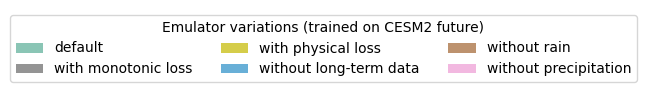

In [26]:
fig, ax = plt.subplots(figsize=(6, 1))
ax.axis("off")

for h in legend_handles:
    h.set_hatch(None)
    h.set_linewidth(0)


fig.legend(
    legend_handles,
    [model_labels.get(l, l) for l in labels],
    title="Emulator variations (trained on CESM2 future)",
    loc="center",
    ncols=3,
)

plt.savefig(os.path.sep.join([out_dir, "legend.pdf"]), bbox_inches="tight")
plt.show()